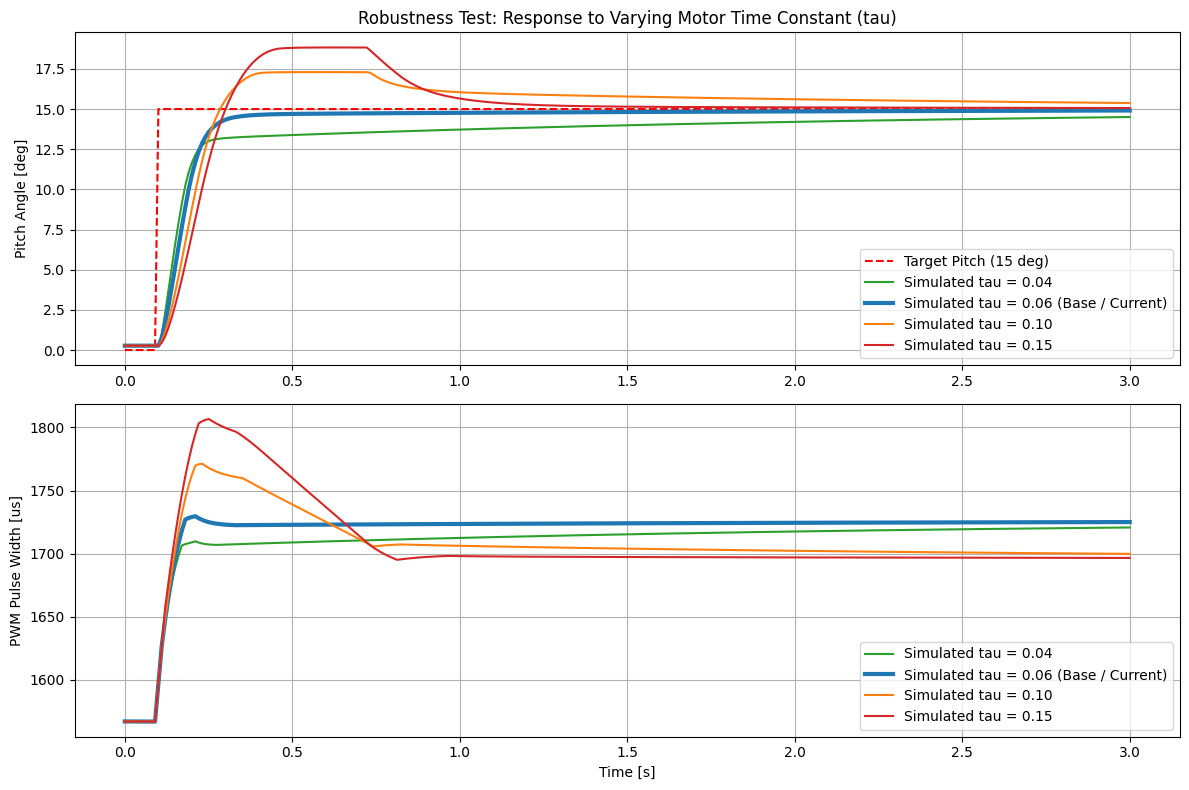

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from collections import deque

# # ==============================================================================
# # 1. チューニング対象パラメータ（ここで試行錯誤を行います）
# # ==============================================================================
# TUNING_PARAMS = {
#     'dead_time_steps': 2,      # むだ時間 (1 step = 10ms。例: 3なら30msの遅延)
#     'tau': 0.06,               # サーボモーターの応答遅れ（時定数）
#     'gravity_max_droop': 4.5,  # 重力による最大垂れ下がり角度 [度/s^2 相当の係数]
#     'damping_factor': 0.8,     # 摩擦係数（自由落下時の減速。1.0:摩擦なし, 0.0:即停止）
#     'backlash_gap': 1.5        # ギアの遊び（バックラッシュ） [±度]
# }

# # ==============================================================================
# # 2. 関数定義ブロック
# # ==============================================================================
# def load_and_preprocess_data(filepath="C:/temp/log.csv"):
#     """実機ログを読み込み、PWMが変化した瞬間をt=0として抽出する"""
#     try:
#         df = pd.read_csv(filepath, names=['Time','Target', 'Actual', 'PWM'])
#     except FileNotFoundError:
#         print("Warning: log.csv が見つからないため、テスト用ダミーデータを生成します。")
#         df = pd.DataFrame({'Time': np.arange(0, 5, 0.01), 'Target': 0, 'Actual': 0.5, 'PWM': 1430})
#         df.loc[10:, 'PWM'] = 1460 # トリガー用にPWMを変化させる

#     # PWMが20以上変化した瞬間を捉える
#     step_idx = df[df['PWM'].diff() > 15].index[0]
    
#     # -0.1秒 ～ +3.0秒 の範囲をスライス
#     start_time = df.loc[step_idx, 'Time'] - 0.1
#     end_time = start_time + 3.0
#     df_plot = df[(df['Time'] >= start_time) & (df['Time'] <= end_time)].copy()
#     df_plot['Time'] = df_plot['Time'] - start_time

#     # 扱いやすいように辞書型でNumPy配列を返す
#     return {
#         'time': df_plot['Time'].values,
#         'pitch': df_plot['Actual'].values,
#         'pwm': df_plot['PWM'].values
#     }

# def calculate_control_pwm_complete(target, current_pitch, current_velocity, current_pwm, dt):
#     """
#     未来予測型ハイブリッドコントローラ（完全版）
#     """
#     Kp = 110.0  # 接近用の推進力
#     Kd = -2.0  # 全体のブレーキ
#     Ki = 5.0   # 不感帯内の最終押し込み力
#     PREDICT_TIME = 0.02  # 20ms先を予測

#     error = target - current_pitch
    
#     # 未来の誤差を予測する
#     future_error = error - (current_velocity * PREDICT_TIME)
#     future_error_abs = abs(future_error)
    
#     speed = 0.0

#     if future_error_abs > 10.0:
#         # 1. 大ズレ：バンバン制御
#         speed = 3000.0 if error > 0.0 else -3000.0

#     elif future_error_abs > 4.0:
#         # 2. 接近フェーズ (全力のKp)
#         speed = (Kp * error) + (Kd * current_velocity)
        
#     elif future_error_abs > 2.0:
#         # 3. 最終着地フェーズ (★ここを修正！ active_errorは使わずKpを弱めるだけ)
#         Kp_soft = Kp * 0.4
#         speed = (Kp_soft * error) + (Kd * current_velocity)
        
#     else:
#         # 4. 不感帯 (±2度以内)
#         if current_velocity > 5.0 or current_velocity < -5.0:
#             speed = Kd * current_velocity
#         else:
#             speed = Ki * error  # ここで最後まで押し切る！

#     # スピードリミット
#     speed = np.clip(speed, -4000.0, 4000.0)

#     # 最終出力
#     new_pwm = current_pwm + (speed * dt)
#     return np.clip(new_pwm, 600.0, 2400.0)

# # def calculate_control_pwm(target, current_pitch, current_velocity, current_pwm, dt):
#     """マイコン側のコントローラ処理（ハイブリッドPID）"""
#     Kp, Ki, Kd = 30.0, 1.5, -2.0
    
#     error = target - current_pitch
#     derivative = current_velocity
#     error_abs = abs(error)

#     if error_abs > 10.0:
#         # 1. 大ズレ：バンバン制御
#         speed = 3000.0 if error > 0 else -3000.0
#     elif error_abs > 4.0:
#         # 2. 接近フェーズ
#         speed = (Kp * error) + (Kd * derivative)
#     elif error_abs > 2.0:
#         # 3. 最終着地フェーズ
#         active_error = (error - 2.0) if error > 0.0 else (error + 2.0)
#         speed = (Kp * active_error) + (Kd * derivative)
#     else:
#         # 4. 不感帯
#         if derivative > 5.0 or derivative < -5.0:
#             speed = Kd * derivative
#         else:
#             speed = Ki * error
    
#     # 積分とフェールセーフ
#     new_pwm = current_pwm + speed * dt
#     return np.clip(new_pwm, 600.0, 2400.0)

# def run_simulation(real_data, params):
#     """物理モデルのシミュレーションループ"""
#     dt = 0.01          # 制御周期 10ms
#     sim_time = 3.0     # シミュレーション時間
#     n_steps = int(sim_time / dt)
#     base_max_speed = 1.75
#     pwm_to_deg = 1.0 / 10.0

#     # 記録用配列の準備
#     time_data = np.linspace(0, sim_time, n_steps)
#     pitch_data = np.zeros(n_steps)
#     pwm_data = np.zeros(n_steps)
#     target_data = np.where(time_data < 0.1, 0.0, 15.0)

#     # 実機データからの初期化
#     initial_pitch = real_data['pitch'][0]
#     initial_pwm = real_data['pwm'][0]
    
#     current_pitch = initial_pitch
#     previous_pitch = initial_pitch
#     current_velocity = 0.0
#     current_pwm = initial_pwm

#     # 機体固有のオフセット計算
#     servo_internal_pitch = initial_pitch + params['backlash_gap']
#     pwm_center_offset = initial_pwm - (servo_internal_pitch / pwm_to_deg)

#     # むだ時間用キュー
#     delay_queue = deque([initial_pwm] * max(1, params['dead_time_steps']), 
#                         maxlen=max(1, params['dead_time_steps']))

#     pitch_data[0] = current_pitch
#     pwm_data[0] = current_pwm

#     pid_state = {
#         'initial_pwm': initial_pwm,
#         'prev_error': 0.0,
#         'prev2_error': 0.0,
#         'pid_integral': 0.0
#     }

#     # メインループ
#     for i in range(1, n_steps):
#         target = target_data[i]
        
#         # 新しい関数を呼び出す
#         current_pwm = calculate_control_pwm_complete(
#             target, current_pitch, current_velocity, current_pwm, dt
#         )
#         pwm_data[i] = current_pwm

#         # # [A] コントローラ (関数呼び出し)
#         # current_pwm = calculate_control_pwm(target, current_pitch, current_velocity, current_pwm, dt)
#         # pwm_data[i] = current_pwm
        
#         # [B] むだ時間処理
#         if params['dead_time_steps'] > 0:
#             delay_queue.append(current_pwm)
#             effective_pwm = delay_queue[0]
#         else:
#             effective_pwm = current_pwm

#         # [C] プラント（物理）モデル計算
#         # --- ① 新規追加：ギア噛み合い時の「静的な重力垂れ下がり(負け)」 ---
#         # ジンバルが水平(90度)に近いほど自重の負荷が大きくなり、角度が下がる
#         gravity_droop = params['gravity_max_droop'] * np.sin(np.radians(current_pitch))
        
#         # モーターの実際の到達位置は、PWM指示から「重力による負け分」を引いた位置
#         servo_target_pitch = ((effective_pwm - pwm_center_offset) * pwm_to_deg) - gravity_droop
        
#         # 一次遅れ系（時定数 TAU）によるモーターの移動量計算
#         delta_pitch = (servo_target_pitch - servo_internal_pitch) * (dt / params['tau'])
        
#         # 負荷減速モデル
#         load_factor = 1.0 - (abs(current_pitch) * 0.01) 
#         max_speed = base_max_speed * max(0.5, load_factor)
        
#         delta_pitch = np.clip(delta_pitch, -max_speed, max_speed)
#         servo_internal_pitch += delta_pitch
        
#         # --- ② 従来通り：バックラッシュ内の自由落下における「動的な重力加速度」 ---
#         # ジンバルを下へ引っ張る加速度（これは絶対になくなりません！）
#         gravity_accel = -params['gravity_max_droop'] * np.sin(np.radians(current_pitch))
        
#         if current_pitch > servo_internal_pitch + params['backlash_gap']:
#             current_pitch = servo_internal_pitch + params['backlash_gap']
#             current_velocity = (current_pitch - previous_pitch) / dt
#         elif current_pitch < servo_internal_pitch - params['backlash_gap']:
#             current_pitch = servo_internal_pitch - params['backlash_gap']
#             current_velocity = (current_pitch - previous_pitch) / dt
#         else:
#             # バックラッシュ内の自由落下と摩擦ダンピング
#             current_velocity += gravity_accel * dt
#             current_velocity *= params['damping_factor']
#             current_pitch += current_velocity * dt
            
#         previous_pitch = current_pitch
#         pitch_data[i] = current_pitch

#     return time_data, target_data, pitch_data, pwm_data

# def plot_results(time_data, target_data, pitch_data, pwm_data, real_data):
#     """波形の可視化"""
#     fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

#     ax1.plot(time_data, target_data, 'r--', label='Target Pitch (15 deg)')
#     ax1.plot(time_data, pitch_data, 'b-', linewidth=2, label='Simulated Pitch (MBD)')
#     ax1.plot(real_data['time'], real_data['pitch'], 'g-', alpha=0.6, label='Actual Pitch (Real)')
#     ax1.set_title('MobilityDynamicsSystem - MBD Simulation (Refactored)')
#     ax1.set_ylabel('Pitch Angle [deg]')
#     ax1.grid(True)
#     ax1.legend()

#     ax2.plot(time_data, pwm_data, 'b-', linewidth=2, label='Simulated Output (PWM)')
#     ax2.plot(real_data['time'], real_data['pwm'], 'g-', alpha=0.6, label='Actual Output (PWM)')
#     ax2.set_ylabel('PWM Pulse Width [us]')
#     ax2.set_xlabel('Time [s]')
#     ax2.grid(True)
#     ax2.legend()

#     plt.tight_layout()
#     plt.show()

# # ==============================================================================
# # 3. メイン実行ブロック
# # ==============================================================================
# if __name__ == "__main__":
#     # 1. データの読み込み
#     real_data = load_and_preprocess_data("C:/temp/log.csv")
    
#     # 2. シミュレーションの実行
#     time_data, target_data, pitch_data, pwm_data = run_simulation(real_data, TUNING_PARAMS)
    
#     # 3. 結果のプロット
#     plot_results(time_data, target_data, pitch_data, pwm_data, real_data)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

# ==============================================================================
# 1. 関数定義ブロック（既存のコードと同じ）
# ==============================================================================
def load_and_preprocess_data(filepath="C:/temp/log.csv"):
    try:
        df = pd.read_csv(filepath, names=['Time','Target', 'Actual', 'PWM'])
    except FileNotFoundError:
        print("Warning: log.csv が見つからないため、テスト用ダミーデータを生成します。")
        df = pd.DataFrame({'Time': np.arange(0, 5, 0.01), 'Target': 0, 'Actual': 0.5, 'PWM': 1430})
        df.loc[10:, 'PWM'] = 1460

    step_idx = df[df['PWM'].diff() > 15].index[0]
    
    start_time = df.loc[step_idx, 'Time'] - 0.1
    end_time = start_time + 3.0
    df_plot = df[(df['Time'] >= start_time) & (df['Time'] <= end_time)].copy()
    df_plot['Time'] = df_plot['Time'] - start_time

    return {
        'time': df_plot['Time'].values,
        'pitch': df_plot['Actual'].values,
        'pwm': df_plot['PWM'].values
    }

def calculate_control_pwm_complete(target, current_pitch, current_velocity, current_pwm, dt):
    Kp = 110.0  
    Kd = -2.0  
    Ki = 5.0   
    PREDICT_TIME = 0.02  

    error = target - current_pitch
    future_error = error - (current_velocity * PREDICT_TIME)
    future_error_abs = abs(future_error)
    
    speed = 0.0

    if future_error_abs > 10.0:
        speed = 3000.0 if error > 0.0 else -3000.0
    elif future_error_abs > 4.0:
        speed = (Kp * error) + (Kd * current_velocity)
    elif future_error_abs > 2.0:
        Kp_soft = Kp * 0.4
        speed = (Kp_soft * error) + (Kd * current_velocity)
    else:
        if current_velocity > 5.0 or current_velocity < -5.0:
            speed = Kd * current_velocity
        else:
            speed = Ki * error

    speed = np.clip(speed, -4000.0, 4000.0)
    new_pwm = current_pwm + (speed * dt)
    return np.clip(new_pwm, 600.0, 2400.0)


def run_simulation(real_data, params):
    dt = 0.01
    sim_time = 3.0
    n_steps = int(sim_time / dt)
    base_max_speed = 1.75
    pwm_to_deg = 1.0 / 10.0

    time_data = np.linspace(0, sim_time, n_steps)
    pitch_data = np.zeros(n_steps)
    pwm_data = np.zeros(n_steps)
    target_data = np.where(time_data < 0.1, 0.0, 15.0)

    initial_pitch = real_data['pitch'][0]
    initial_pwm = real_data['pwm'][0]
    
    current_pitch = initial_pitch
    previous_pitch = initial_pitch
    current_velocity = 0.0
    current_pwm = initial_pwm

    servo_internal_pitch = initial_pitch + params['backlash_gap']
    pwm_center_offset = initial_pwm - (servo_internal_pitch / pwm_to_deg)

    delay_queue = deque([initial_pwm] * max(1, params['dead_time_steps']), 
                        maxlen=max(1, params['dead_time_steps']))

    pitch_data[0] = current_pitch
    pwm_data[0] = current_pwm

    for i in range(1, n_steps):
        target = target_data[i]
        
        current_pwm = calculate_control_pwm_complete(
            target, current_pitch, current_velocity, current_pwm, dt
        )
        pwm_data[i] = current_pwm
        
        if params['dead_time_steps'] > 0:
            delay_queue.append(current_pwm)
            effective_pwm = delay_queue[0]
        else:
            effective_pwm = current_pwm

        gravity_droop = params['gravity_max_droop'] * np.sin(np.radians(current_pitch))
        servo_target_pitch = ((effective_pwm - pwm_center_offset) * pwm_to_deg) - gravity_droop
        
        delta_pitch = (servo_target_pitch - servo_internal_pitch) * (dt / params['tau'])
        
        load_factor = 1.0 - (abs(current_pitch) * 0.01) 
        max_speed = base_max_speed * max(0.5, load_factor)
        
        delta_pitch = np.clip(delta_pitch, -max_speed, max_speed)
        servo_internal_pitch += delta_pitch
        
        gravity_accel = -params['gravity_max_droop'] * np.sin(np.radians(current_pitch))
        
        if current_pitch > servo_internal_pitch + params['backlash_gap']:
            current_pitch = servo_internal_pitch + params['backlash_gap']
            current_velocity = (current_pitch - previous_pitch) / dt
        elif current_pitch < servo_internal_pitch - params['backlash_gap']:
            current_pitch = servo_internal_pitch - params['backlash_gap']
            current_velocity = (current_pitch - previous_pitch) / dt
        else:
            current_velocity += gravity_accel * dt
            current_velocity *= params['damping_factor']
            current_pitch += current_velocity * dt
            
        previous_pitch = current_pitch
        pitch_data[i] = current_pitch

    return time_data, target_data, pitch_data, pwm_data

# ==============================================================================
# 2. ロバスト性検証ブロック（複数tauの比較プロット）
# ==============================================================================
def plot_robustness_test(real_data):
    """tauを変動させてシミュレーションを回し、結果を重ねてプロットする"""
    
    # ベースとなる物理パラメータ
    base_params = {
        'dead_time_steps': 2,
        'gravity_max_droop': 4.5,
        'damping_factor': 0.8,
        'backlash_gap': 1.5
    }

    # テストする時定数 tau のリスト（小さいほど機敏、大きいほど鈍重）
    tau_test_values = [0.04, 0.06, 0.10, 0.15]
    
    # 見分けやすくするためのカラーパレット
    colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'] 

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

    # 1. ターゲット線の描画（基準）
    time_data_mock, target_data, _, _ = run_simulation(real_data, {**base_params, 'tau': 0.06})
    ax1.plot(time_data_mock, target_data, 'r--', label='Target Pitch (15 deg)')
    
    # （オプション）実機データ（緑太線）を背景に薄く表示しておく場合
    # ax1.plot(real_data['time'], real_data['pitch'], 'k-', alpha=0.2, linewidth=4, label='Actual Pitch (Reference)')
    # ax2.plot(real_data['time'], real_data['pwm'], 'k-', alpha=0.2, linewidth=4, label='Actual Output (Reference)')

    # 2. tauを切り替えながらシミュレーション＆描画
    for i, tau in enumerate(tau_test_values):
        test_params = base_params.copy()
        test_params['tau'] = tau
        
        # シミュレーション実行
        time_data, _, pitch_data, pwm_data = run_simulation(real_data, test_params)
        
        # 凡例ラベルの作成
        label_str = f'Simulated tau = {tau:.2f}'
        if tau == 0.06:
            label_str += ' (Base / Current)'
            linewidth = 3.0  # ベースは線を太くする
        else:
            linewidth = 1.5

        # グラフへのプロット
        ax1.plot(time_data, pitch_data, color=colors[i], linewidth=linewidth, label=label_str)
        ax2.plot(time_data, pwm_data, color=colors[i], linewidth=linewidth, label=label_str)

    # グラフの装飾設定
    ax1.set_title('Robustness Test: Response to Varying Motor Time Constant (tau)')
    ax1.set_ylabel('Pitch Angle [deg]')
    ax1.grid(True)
    ax1.legend(loc='lower right')

    ax2.set_ylabel('PWM Pulse Width [us]')
    ax2.set_xlabel('Time [s]')
    ax2.grid(True)
    ax2.legend(loc='lower right')

    plt.tight_layout()
    plt.show()

# ==============================================================================
# 3. メイン実行
# ==============================================================================
if __name__ == "__main__":
    real_data = load_and_preprocess_data("C:/temp/log.csv")
    plot_robustness_test(real_data)